# 03 Analysis of HOMER Output

## Initialize

In [1]:
# Initialize Environment
# Do I really need all these libraries?
# Who knows, but they are here now
library(ggplot2)
library(ggpubr)
library(ggsci)
library(ggprism)
library(dplyr)
library(tidyr)
library(viridis)

# Set working directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/cutnrun")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite



In [2]:
# Read homer results for cluster 1 and cluster 2
cluster_1_homer <- read.csv("03_motif/cluster_1_homer_VS_allGenome.csv")
cluster_2_homer <- read.csv("03_motif/cluster_2_homer_VS_allGenome.csv")

In [3]:
# Make new column normalized enrichment (OddsRatio) for each motif in cluster 1 and cluster 2
# Which is (TargetPercent)/BackgroundPercent
cluster_1_homer <- cluster_1_homer %>%
    mutate(OddsRatio = TargetPercent / BackgroundPercent)

cluster_2_homer <- cluster_2_homer %>%
    mutate(OddsRatio = TargetPercent / BackgroundPercent)

head(cluster_1_homer)
head(cluster_2_homer)

,TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,RUNX,Runt,HPC7-Runx1-ChIP-Seq,GSE22178,Homer,SAAACCACAG,0e+00,0,1767,63.36,20619.8,27.39,2.313253
2,RUNX-AML,Runt,CD4+-PolII-ChIP-Seq,Barski_et_al.,Homer,GCTGTGGTTW,1e-232,0,1569,56.26,20238.5,26.89,2.092228
3,RUNX1,Runt,Jurkat-RUNX1-ChIP-Seq,GSE29180,Homer,AAACCACARM,1e-213,0,1896,67.98,29128.9,38.70,1.756589
4,RUNX2,Runt,PCa-RUNX2-ChIP-Seq,GSE33889,Homer,NWAACCACADNN,1e-198,0,1650,59.16,23666.0,31.44,1.881679
5,ETS1,ETS,Jurkat-ETS1-ChIP-Seq,GSE17954,Homer,ACAGGAAGTG,1e-178,0,1886,67.62,30725.5,40.82,1.656541
6,ETS:RUNX,ETS:Runt,Jurkat-RUNX1-ChIP-Seq,GSE17954,Homer,RCAGGATGTGGT,1e-170,0,496,17.78,2979.3,3.96,4.489899


,TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,RUNX,Runt,HPC7-Runx1-ChIP-Seq,GSE22178,Homer,SAAACCACAG,0e+00,0,3304,54.89,20772.7,29.07,1.888201
2,RUNX-AML,Runt,CD4+-PolII-ChIP-Seq,Barski_et_al.,Homer,GCTGTGGTTW,1e-286,0,3044,50.57,20272.7,28.37,1.782517
3,Elk4,ETS,Hela-Elk4-ChIP-Seq,GSE31477,Homer,NRYTTCCGGY,1e-272,0,3065,50.92,20843.0,29.16,1.746228
4,Fli1,ETS,CD8-FLI-ChIP-Seq,GSE20898,Homer,NRYTTCCGGH,1e-272,0,4267,70.89,34607.9,48.43,1.463762
5,ETS1,ETS,Jurkat-ETS1-ChIP-Seq,GSE17954,Homer,ACAGGAAGTG,1e-268,0,3938,65.43,30721.4,42.99,1.521982
6,ELF1,ETS,Jurkat-ELF1-ChIP-Seq,SRA014231,Homer,AVCCGGAAGT,1e-256,0,2847,47.30,19021.4,26.62,1.776860


In [4]:
# Keep only QValue < 0.05
cluster_1_homer <- cluster_1_homer %>%
    filter(QValue < 0.05)
cluster_2_homer <- cluster_2_homer %>%
    filter(QValue < 0.05)

In [5]:
# View all entries with a ? in FamilyName
cluster_1_homer %>%
    filter(grepl("\\?", FamilyName))

TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BANP,?,ESC-Banp-ChIP-Seq,GSE155603,Homer,TCTCGCGAGANY,1e-24,0.000,251,9.00,3324.0,4.42,2.036199
GFY,?,Promoter,,Homer,ACTACAATTCCC,1e-24,0.000,182,6.53,2094.4,2.78,2.348921
GFY-Staf,?:Zf,Promoter,,Homer,RACTACAATTCCCAGAAKGC,1e-23,0.000,166,5.95,1870.2,2.48,2.399194
GFX,?,Promoter,,Homer,ATTCTCGCGAGA,1e-11,0.000,55,1.97,497.1,0.66,2.984848
CHR,?,Hela-CellCycle-Expression,,Homer,SRGTTTCAAA,1e-03,0.001,596,21.37,14102.8,18.73,1.140950


In [6]:
# View all entries with a ? in FamilyName
cluster_2_homer %>%
    filter(grepl("\\?", FamilyName))

TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GFY-Staf,?:Zf,Promoter,,Homer,RACTACAATTCCCAGAAKGC,1e-47,0.0000,365,6.06,1846.4,2.58,2.348837
GFY,?,Promoter,,Homer,ACTACAATTCCC,1e-42,0.0000,375,6.23,2035.2,2.85,2.185965
BANP,?,ESC-Banp-ChIP-Seq,GSE155603,Homer,TCTCGCGAGANY,1e-11,0.0000,423,7.03,3591.8,5.03,1.397614
CHR,?,Hela-CellCycle-Expression,,Homer,SRGTTTCAAA,1e-10,0.0000,1440,23.92,14599.8,20.43,1.170827
GFX,?,Promoter,,Homer,ATTCTCGCGAGA,1e-09,0.0000,84,1.40,460.5,0.64,2.187500
HuR,?,HEK293-HuR-CLIP-Seq,GSE87887,Homer,BTTTGGTTTG,1e-03,0.0005,5032,83.60,58481.6,81.83,1.021630
GEI-11,Myb?,cElegans-L4-GEI11-ChIP-Seq,modEncode,Homer,CCGACAYYTYACGGG,1e-02,0.0073,192,3.19,1854.3,2.59,1.231660


In [7]:
# Remove all entries with a ? or blank in FamilyName
# Remove all entries with Promoter in TF, FamilyName, or Assay
cluster_1_homer <- cluster_1_homer %>%
    filter(!grepl("\\?", FamilyName) & FamilyName != "" & !grepl("Promoter|promoter", paste(TF, FamilyName, Assay)))
cluster_2_homer <- cluster_2_homer %>%
    filter(!grepl("\\?", FamilyName) & FamilyName != "" & !grepl("Promoter|promoter", paste(TF, FamilyName, Assay)))

In [8]:
# See unique values of FamilyName in descending order
family_counts <- table(cluster_1_homer$FamilyName)
family_counts <- sort(family_counts, decreasing = TRUE)
family_counts


       AP2EREBP            bZIP              Zf             MYB            bHLH 
             58              43              33              32              25 
            ETS            WRKY        Homeobox             NAC             E2F 
             20              18              11              11               9 
            HTH            C2H2             IRF        Trihelix           T-box 
              8               7               7               7               6 
            RHD    Homeobox:POU          LOBAS2            Runt             C3H 
              5               4               4               4               3 
       bZIP:IRF           CAMTA           E2FDP         ETS:IRF        Forkhead 
              2               2               2               2               2 
     MYBrelated              NR             ARF        bHLH:ETS         bHLH:Zf 
              2               2               1               1               1 
            BLH        bZIP

In [9]:
# See unique values of FamilyName in descending order
family_counts <- table(cluster_2_homer$FamilyName)
family_counts <- sort(family_counts, decreasing = TRUE)
family_counts


        AP2EREBP             bZIP               Zf              MYB 
              60               53               39               36 
            bHLH              NAC              ETS         Homeobox 
              27               24               20               10 
             E2F              HTH         Trihelix             WRKY 
               9                9                9                9 
             IRF             Stat             C2H2            T-box 
               7                7                6                6 
        Forkhead              HMG           LOBAS2               NR 
               5                5                5                5 
             RHD              SBP     Homeobox:POU             MADS 
               5                5                4                4 
      MYBrelated             Runt              C3H              CPP 
               4                4                3                3 
           E2FDP          ABI3VP1

In [10]:
# Remove plant TFs
# If FamilyName is:
# "AP2EREBP",
# "WRKY",
# "NAC",
# "LOBAS2",
# "BLH",
# "C2C2dof",
# "FAR1",
# "GRF",
# "mTERF",
# "REMB3",
# "SBP",
# "SRS",
# "TCP",
# "MADS",
# "CAMTA",
# "CPP",
# "ABI3VP1",
# "BZR",
# "G2like",
# "RWPRK",
# "ARF",
# "BES1" or 
# Accession is "GSE60143"

cluster_1_homer <- cluster_1_homer %>%
    filter(!FamilyName %in% c("AP2EREBP", "WRKY", "NAC", "LOBAS2", "BLH", "C2C2dof", "FAR1", "GRF", "mTERF", "REMB3", "SBP", "SRS", "TCP", "MADS", "CAMTA", "CPP", "ABI3VP1", "BZR", "G2like", "RWPRK", "ARF", "BES1", "MYB") & Accession != "GSE60143")
cluster_2_homer <- cluster_2_homer %>%
    filter(!FamilyName %in% c("AP2EREBP", "WRKY", "NAC", "LOBAS2", "BLH", "C2C2dof", "FAR1", "GRF", "mTERF", "REMB3", "SBP", "SRS", "TCP", "MADS", "CAMTA", "CPP", "ABI3VP1", "BZR", "G2like", "RWPRK", "ARF", "BES1", "MYB") & Accession != "GSE60143")

In [11]:
# See unique values of FamilyName in descending order
family_counts <- table(cluster_1_homer$FamilyName)
family_counts <- sort(family_counts, decreasing = TRUE)
family_counts


             Zf            bZIP             ETS            bHLH             E2F 
             33              27              20              17               9 
       Homeobox             HTH             IRF           T-box             RHD 
              9               8               7               6               5 
   Homeobox:POU            Runt        bZIP:IRF         ETS:IRF        Forkhead 
              4               4               2               2               2 
             NR        bHLH:ETS         bHLH:Zf        bZIP:RHD        ETS:Runt 
              2               1               1               1               1 
            HLH Homeobox:Paired             NRF             RRM            THAP 
              1               1               1               1               1 

In [12]:
# See unique values of FamilyName in descending order
family_counts <- table(cluster_2_homer$FamilyName)
family_counts <- sort(family_counts, decreasing = TRUE)
family_counts


              Zf             bZIP              ETS             bHLH 
              39               30               20               17 
             E2F              HTH         Homeobox              IRF 
               9                9                7                7 
            Stat            T-box         Forkhead              HMG 
               7                6                5                5 
              NR              RHD     Homeobox:POU             Runt 
               5                5                4                4 
        bZIP:IRF          ETS:IRF              HLH         bHLH:ETS 
               2                2                2                1 
              DM         ETS:Runt      Forkhead:NR HMG:Homeobox:POU 
               1                1                1                1 
 Homeobox:Paired        MAD:T-box              NRF             THAP 
               1                1                1                1 

In [13]:
head(cluster_1_homer)

,TF,FamilyName,Assay,Accession,Database,Consensus,PValue,QValue,TargetNumber,TargetPercent,BackgroundNumber,BackgroundPercent,OddsRatio
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,RUNX,Runt,HPC7-Runx1-ChIP-Seq,GSE22178,Homer,SAAACCACAG,0e+00,0,1767,63.36,20619.8,27.39,2.313253
2,RUNX-AML,Runt,CD4+-PolII-ChIP-Seq,Barski_et_al.,Homer,GCTGTGGTTW,1e-232,0,1569,56.26,20238.5,26.89,2.092228
3,RUNX1,Runt,Jurkat-RUNX1-ChIP-Seq,GSE29180,Homer,AAACCACARM,1e-213,0,1896,67.98,29128.9,38.70,1.756589
4,RUNX2,Runt,PCa-RUNX2-ChIP-Seq,GSE33889,Homer,NWAACCACADNN,1e-198,0,1650,59.16,23666.0,31.44,1.881679
5,ETS1,ETS,Jurkat-ETS1-ChIP-Seq,GSE17954,Homer,ACAGGAAGTG,1e-178,0,1886,67.62,30725.5,40.82,1.656541
6,ETS:RUNX,ETS:Runt,Jurkat-RUNX1-ChIP-Seq,GSE17954,Homer,RCAGGATGTGGT,1e-170,0,496,17.78,2979.3,3.96,4.489899


In [31]:
id_cols <- c("TF", "FamilyName", "Assay", "Accession", "Database", "Consensus")

combined_homer <- full_join(
        cluster_1_homer,
        cluster_2_homer,
        by = id_cols,
        suffix = c("_cluster1", "_cluster2")
    ) %>%
    mutate(
        PValue_cluster1 = coalesce(PValue_cluster1, 1),
        PValue_cluster2 = coalesce(PValue_cluster2, 1),
        QValue_cluster1 = coalesce(QValue_cluster1, 1),
        QValue_cluster2 = coalesce(QValue_cluster2, 1),
        OddsRatio_cluster1 = coalesce(OddsRatio_cluster1, 0.5),
        OddsRatio_cluster2 = coalesce(OddsRatio_cluster2, 0.5),
        TargetPercent_cluster1 = coalesce(TargetPercent_cluster1, 0.5),
        TargetPercent_cluster2 = coalesce(TargetPercent_cluster2, 0.5)
    )

In [20]:
head(x = combined_homer)
write.csv(combined_homer, "03_motif/combined_homer_results.csv", row.names = FALSE)

,TF,FamilyName,Assay,Accession,Database,Consensus,PValue_cluster1,QValue_cluster1,TargetNumber_cluster1,TargetPercent_cluster1,BackgroundNumber_cluster1,BackgroundPercent_cluster1,OddsRatio_cluster1,PValue_cluster2,QValue_cluster2,TargetNumber_cluster2,TargetPercent_cluster2,BackgroundNumber_cluster2,BackgroundPercent_cluster2,OddsRatio_cluster2
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,RUNX,Runt,HPC7-Runx1-ChIP-Seq,GSE22178,Homer,SAAACCACAG,0e+00,0,1767,63.36,20619.8,27.39,2.313253,0e+00,0,3304,54.89,20772.7,29.07,1.888201
2,RUNX-AML,Runt,CD4+-PolII-ChIP-Seq,Barski_et_al.,Homer,GCTGTGGTTW,1e-232,0,1569,56.26,20238.5,26.89,2.092228,1e-286,0,3044,50.57,20272.7,28.37,1.782517
3,RUNX1,Runt,Jurkat-RUNX1-ChIP-Seq,GSE29180,Homer,AAACCACARM,1e-213,0,1896,67.98,29128.9,38.70,1.756589,1e-247,0,3727,61.92,28842.0,40.36,1.534192
4,RUNX2,Runt,PCa-RUNX2-ChIP-Seq,GSE33889,Homer,NWAACCACADNN,1e-198,0,1650,59.16,23666.0,31.44,1.881679,1e-224,0,3262,54.20,24300.7,34.00,1.594118
5,ETS1,ETS,Jurkat-ETS1-ChIP-Seq,GSE17954,Homer,ACAGGAAGTG,1e-178,0,1886,67.62,30725.5,40.82,1.656541,1e-268,0,3938,65.43,30721.4,42.99,1.521982
6,ETS:RUNX,ETS:Runt,Jurkat-RUNX1-ChIP-Seq,GSE17954,Homer,RCAGGATGTGGT,1e-170,0,496,17.78,2979.3,3.96,4.489899,1e-210,0,843,14.01,2888.9,4.04,3.467822


In [21]:
families <- unique(combined_homer$FamilyName)

# Make a palette
library(paletteer)
pal <- paletteer_d("ggsci::category20_d3")
pal <- as.character(pal)
pal <- pal[1:length(c(families, "Other"))]
names(pal) <- c(families, "Other")

In [27]:
library(ggrepel)
library(MASS)

label_tfs <- c("RUNX", "RUNX-AML", "RUNX1", "RUNX2", "ETS1", "ETS:RUNX",
               "Fli1", "KLF3", "Jun-AP1", "AP-1", "Tbx21", "Tbet",
               "Stat3", "STAT4", "STAT5", "Tcf7", "PU.1:IRF8")

# rows to label
to_label <- combined_homer %>%
  filter(!is.na(TF) & TF %in% label_tfs) %>%
  mutate(x = as.numeric(OddsRatio_cluster2),
         y = as.numeric(OddsRatio_cluster1))

# compute kde on the full point cloud (not just labeled points) for density context
kde <- MASS::kde2d(x = combined_homer$OddsRatio_cluster2,
                    y = combined_homer$OddsRatio_cluster1,
                    n = 120)

ix <- findInterval(to_label$x, kde$x)
iy <- findInterval(to_label$y, kde$y)
ix <- pmin(pmax(ix, 1), length(kde$x))
iy <- pmin(pmax(iy, 1), length(kde$y))
dens_vals <- kde$z[cbind(ix, iy)]
to_label$density <- dens_vals

density_cutoff <- quantile(to_label$density, probs = 0.4, na.rm = TRUE)
to_label$high_density <- ifelse(is.na(to_label$density), FALSE, to_label$density > density_cutoff)

to_label_high <- to_label %>% filter(high_density)
to_label_low  <- to_label %>% filter(!high_density)

p <- ggplot(combined_homer, aes(x = OddsRatio_cluster2, y = OddsRatio_cluster1, color = FamilyName)) +
  scale_color_manual(values = pal) +
  geom_point(size = 3, alpha = 0.7) +
  theme_classic() +
  # crowded points (high density): stronger repulsion, tighter segments
  geom_text_repel(
    data = to_label_high,
    aes(x = x, y = y, label = TF),
    size = 3,
    max.overlaps = Inf,
    box.padding = 0.6,
    point.padding = 0.3,
    force = 3,
    segment.size = 0.3,
    segment.color = "grey40",
    min.segment.length = 0
  ) +
  # sparse points (low density): lighter repulsion, since they have room already
  geom_text_repel(
    data = to_label_low,
    aes(x = x, y = y, label = TF),
    size = 3,
    max.overlaps = Inf,
    box.padding = 0.3,
    point.padding = 0.2,
    force = 1,
    segment.size = 0.3,
    segment.color = "grey40",
    min.segment.length = 0
  ) +
  labs(x = "Odds Ratio (Cluster 2)", y = "Odds Ratio (Cluster 1)", color = "Family Name") +
  theme(legend.position = "right", legend.title = element_text(size = 10),
        legend.text = element_text(size = 8), aspect.ratio = 1)

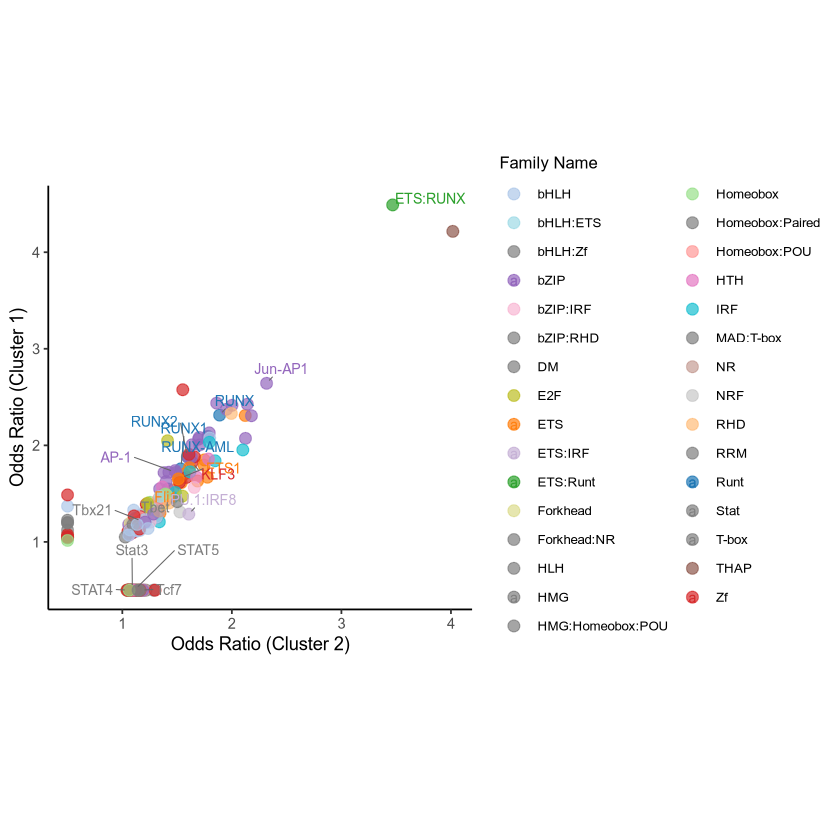

In [28]:
print(p)

In [32]:
label_tfs <- c("RUNX", "RUNX-AML", "RUNX1", "RUNX2", "ETS1", "ETS:RUNX",
               "Fli1", "KLF3", "Jun-AP1", "AP-1", "Tbx21", "Tbet",
               "Stat3", "STAT4", "STAT5", "Tcf7", "PU.1:IRF8")

# rows to label
to_label <- combined_homer %>%
  filter(!is.na(TF) & TF %in% label_tfs) %>%
  mutate(x = as.numeric(TargetPercent_cluster2),
         y = as.numeric(TargetPercent_cluster1))

# compute kde on the full point cloud (not just labeled points) for density context
kde <- MASS::kde2d(x = combined_homer$TargetPercent_cluster2,
                    y = combined_homer$TargetPercent_cluster1,
                    n = 120)

ix <- findInterval(to_label$x, kde$x)
iy <- findInterval(to_label$y, kde$y)
ix <- pmin(pmax(ix, 1), length(kde$x))
iy <- pmin(pmax(iy, 1), length(kde$y))
dens_vals <- kde$z[cbind(ix, iy)]
to_label$density <- dens_vals

density_cutoff <- quantile(to_label$density, probs = 0.4, na.rm = TRUE)
to_label$high_density <- ifelse(is.na(to_label$density), FALSE, to_label$density > density_cutoff)

to_label_high <- to_label %>% filter(high_density)
to_label_low  <- to_label %>% filter(!high_density)

p <- ggplot(combined_homer, aes(x = TargetPercent_cluster2, y = TargetPercent_cluster1, color = FamilyName)) +
  scale_color_manual(values = pal) +
  geom_point(size = 3, alpha = 0.7) +
  theme_classic() +
  # crowded points (high density): stronger repulsion, tighter segments
  geom_text_repel(
    data = to_label_high,
    aes(x = x, y = y, label = TF),
    size = 3,
    max.overlaps = Inf,
    box.padding = 0.6,
    point.padding = 0.3,
    force = 3,
    segment.size = 0.3,
    segment.color = "grey40",
    min.segment.length = 0
  ) +
  # sparse points (low density): lighter repulsion, since they have room already
  geom_text_repel(
    data = to_label_low,
    aes(x = x, y = y, label = TF),
    size = 3,
    max.overlaps = Inf,
    box.padding = 0.3,
    point.padding = 0.2,
    force = 1,
    segment.size = 0.3,
    segment.color = "grey40",
    min.segment.length = 0
  ) +
  labs(x = "Target Percent (Cluster 2)", y = "Target Percent (Cluster 1)", color = "Family Name") +
  theme(legend.position = "right", legend.title = element_text(size = 10),
        legend.text = element_text(size = 8), aspect.ratio = 1)

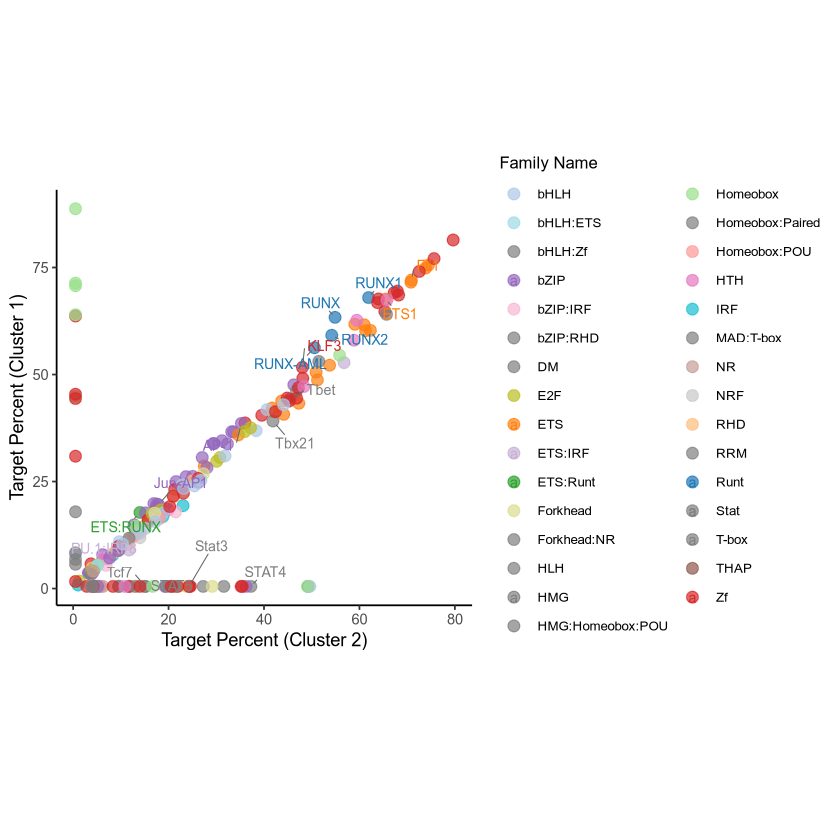

In [33]:
print(p)